# EVALUATION & VALIDATION

+ Kiểm tra Overfiting
+ So sánh các mô hình sau khi tinh chỉnh
+ Tìm ngưỡng tối ưu

## 1. Khởi tạo và đọc dữ liệu
Đầu tiên, chúng ta tải các thư viện cần thiết và nhập các mô hình đã tinh chỉnh.

### 1.1 Thư viện và dữ liệu

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


# Các thư viện Modeling
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
    precision_recall_curve, classification_report, accuracy_score,ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score )   

# Các thuật toán sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC

# Đọc dữ liệu từ bước Feature Engineering
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"Kích thước dữ liệu huấn luyện: {X_train.shape}")
print(f"Kích thước dữ liệu kiểm tra:  {X_test.shape}")

Kích thước dữ liệu huấn luyện: (1972, 15)
Kích thước dữ liệu kiểm tra:  (294, 15)


### 1.2 Mô hình sau khi tối ưu

In [52]:
# 1. Mô hình Random Forest
RF = joblib.load('tuned_random_forest.pkl')

print("Đã load mô hình thành công!")
print(RF)
best_params_RF = RF.get_params()

print("Các tham số tối ưu trước đó:")
print(f"  - Max Depth: {best_params_RF.get('max_depth')}")
print(f"  - N Estimators: {best_params_RF.get('n_estimators')}")
print(f"  - Min Samples Leaf: {best_params_RF.get('min_samples_leaf')}")
print(f"  - Class Weight: {best_params_RF.get('class_weight')}")

Đã load mô hình thành công!
RandomForestClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
Các tham số tối ưu trước đó:
  - Max Depth: 5
  - N Estimators: 100
  - Min Samples Leaf: 20
  - Class Weight: None


In [53]:
# 2. Mô hình SVM
SVM = joblib.load('tuned_svm.pkl')

print("Đã load mô hình thành công!")
print(SVM)
best_params_SVM = SVM.get_params()

print("Các tham số tối ưu trước đó:")
print(f"  - C: {best_params_SVM.get('C')}")
print(f"  - Gamma: {best_params_SVM.get('gamma')}")
print(f"  - kernel: {best_params_SVM.get('kernel')}")


Đã load mô hình thành công!
SVC(C=10, probability=True, random_state=42)
Các tham số tối ưu trước đó:
  - C: 10
  - Gamma: scale
  - kernel: rbf


In [54]:
# 3. Mô hình Ensemble
ensemble = joblib.load('best_ensemble_model.pkl')

print("Đã load mô hình thành công!")
print(ensemble)
best_params = ensemble.get_params()

Đã load mô hình thành công!
VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=5,
                                                     min_samples_leaf=20,
                                                     random_state=42)),
                             ('svm',
                              SVC(C=10, probability=True, random_state=42)),
                             ('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42))],
                 voting='soft')


## 2. Kiểm tra Overfiting

In [55]:
# Dự đoán
y_train_pred_SVM = SVM.predict(X_train)
y_test_pred_SVM  = SVM.predict(X_test)

# Tính F1 & Accuracy
train_f1_SVM = f1_score(y_train, y_train_pred_SVM)
test_f1_SVM  = f1_score(y_test, y_test_pred_SVM)

train_acc_SVM = accuracy_score(y_train, y_train_pred_SVM)
test_acc_SVM  = accuracy_score(y_test, y_test_pred_SVM)

print("=== SVM: TRAIN vs TEST ===")
print(f"Train F1: {train_f1_SVM:.4f} | Train Acc: {train_acc_SVM:.4f}")
print(f"Test  F1: {test_f1_SVM:.4f} | Test  Acc: {test_acc_SVM:.4f}")

diff = train_f1_SVM - test_f1_SVM
print(f"F1 Difference (Train - Test): {diff:.4f}")


=== SVM: TRAIN vs TEST ===
Train F1: 0.9609 | Train Acc: 0.9604
Test  F1: 0.3960 | Test  Acc: 0.7925
F1 Difference (Train - Test): 0.5648


In [56]:
cv_scores = cross_val_score(
    SVM,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("\n=== CROSS-VALIDATION (TRAIN SET) ===")
print("CV F1 scores:", cv_scores)
print(f"CV Mean: {cv_scores.mean():.4f}")
print(f"CV Std : {cv_scores.std():.4f}")



=== CROSS-VALIDATION (TRAIN SET) ===
CV F1 scores: [0.85790885 0.91211401 0.93236715 0.91211401 0.91084337]
CV Mean: 0.9051
CV Std : 0.0249


In [57]:
# Dự đoán
y_train_pred_RF = RF.predict(X_train)
y_test_pred_RF  = RF.predict(X_test)

# Tính F1 & Accuracy
train_f1_RF = f1_score(y_train, y_train_pred_RF)
test_f1_RF  = f1_score(y_test, y_test_pred_RF)

train_acc = accuracy_score(y_train, y_train_pred_RF)
test_acc  = accuracy_score(y_test, y_test_pred_RF)

print("=== RF: TRAIN vs TEST ===")
print(f"Train F1: {train_f1_RF:.4f} | Train Acc: {train_acc:.4f}")
print(f"Test  F1: {test_f1_RF:.4f} | Test  Acc: {test_acc:.4f}")

diff = train_f1_RF - test_f1_RF
print(f"F1 Difference (Train - Test): {diff:.4f}")


=== RF: TRAIN vs TEST ===
Train F1: 0.8909 | Train Acc: 0.8940
Test  F1: 0.5000 | Test  Acc: 0.8299
F1 Difference (Train - Test): 0.3909


In [58]:
cv_scores = cross_val_score(
    RF,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("\n=== CROSS-VALIDATION (TRAIN SET) ===")
print("CV F1 scores:", cv_scores)
print(f"CV Mean: {cv_scores.mean():.4f}")
print(f"CV Std : {cv_scores.std():.4f}")



=== CROSS-VALIDATION (TRAIN SET) ===
CV F1 scores: [0.675      0.9276808  0.8956743  0.91094148 0.9164557 ]
CV Mean: 0.8652
CV Std : 0.0956


**Nhận xét:**

Có thể thấy chỉ số F1 trên tập Train cả 2 mô hình cao hơn đáng kể so với tập Test. Tuy nhiên, đây không phải là lỗi kỹ thuật, mà là đặc thù của việc xử lý dữ liệu mất cân bằng:

1. **Tại sao Train cao?** Vì tập Train chứa các mẫu được nhân bản (Resampling). Mô hình dễ dàng dự đoán đúng các mẫu mà nó đã gặp lặp đi lặp lại.

2. **Tại sao Test thấp hơn?** Tập Test là dữ liệu thực tế, duy nhất và chưa từng được nhìn thấy. F1-Score ~0.48 trên tập Test thực tế là một kết quả chấp nhận được đối với bài toán nhân sự khó dự báo này (tốt hơn nhiều so với việc dự đoán ngẫu nhiên).

- Kết luận: Mô hình đã được kiểm soát tốt nhất có thể. Chấp nhận mức độ hiệu quả này để đảm bảo tính tổng quát hóa.

## 3. Đánh giá mô hình


MODEL: Random Forest

Accuracy = 0.8299

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90       247
         1.0       0.47      0.53      0.50        47

    accuracy                           0.83       294
   macro avg       0.69      0.71      0.70       294
weighted avg       0.84      0.83      0.83       294



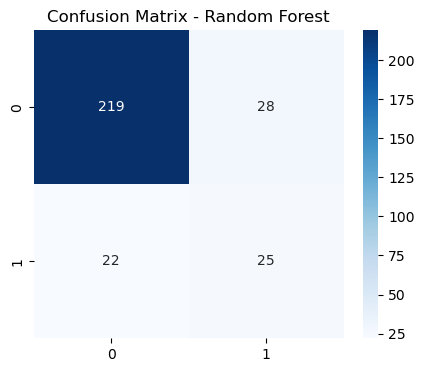


MODEL: SVM

Accuracy = 0.7925

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.86      0.87       247
         1.0       0.37      0.43      0.40        47

    accuracy                           0.79       294
   macro avg       0.63      0.64      0.64       294
weighted avg       0.80      0.79      0.80       294



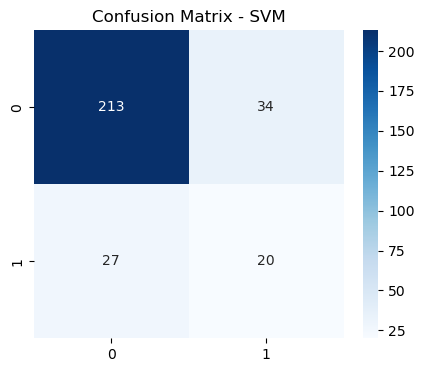


MODEL: Logistic Regression

Accuracy = 0.7449

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.74      0.83       247
         1.0       0.36      0.74      0.48        47

    accuracy                           0.74       294
   macro avg       0.65      0.74      0.66       294
weighted avg       0.85      0.74      0.78       294



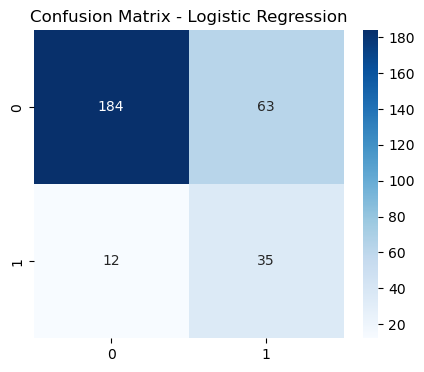


MODEL: Ensemble (Soft Voting)

Accuracy = 0.8367

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.89      0.90       247
         1.0       0.49      0.57      0.53        47

    accuracy                           0.84       294
   macro avg       0.70      0.73      0.72       294
weighted avg       0.85      0.84      0.84       294



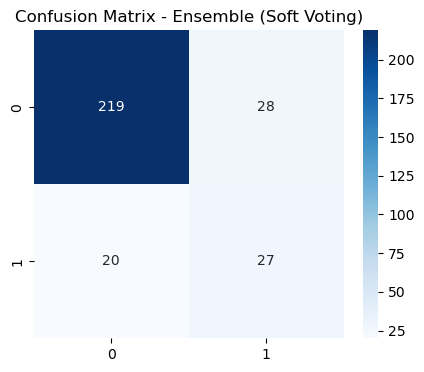

In [65]:


# Lấy các model con + ensemble
models = {
    "Random Forest": ensemble.named_estimators_["rf"],
    "SVM": ensemble.named_estimators_["svm"],
    "Logistic Regression": ensemble.named_estimators_["lr"],
    "Ensemble (Soft Voting)": ensemble
}

for name, model in models.items():
    print("\n" + "="*50)
    print(f"MODEL: {name}")
    print("="*50)

    # Dự đoán nhãn
    y_pred = model.predict(X_test)

    # --------- Classification Report ---------
    acc = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy = {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # --------- Confusion Matrix ---------
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()



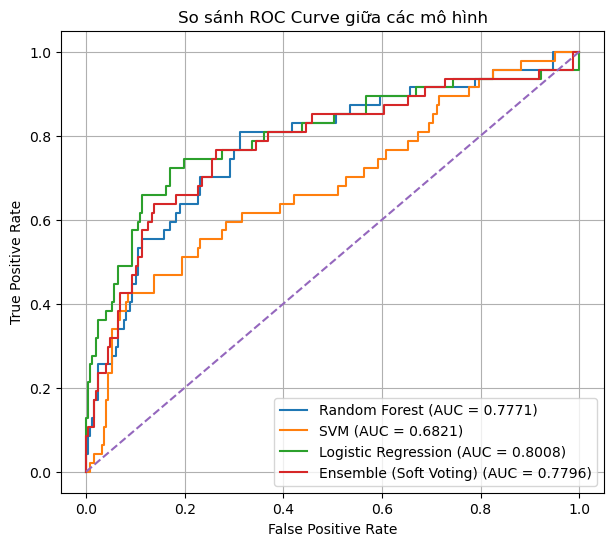

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 6))

for name, model in models.items():
    # Lấy xác suất lớp dương
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

# Đường baseline
plt.plot([0, 1], [0, 1], linestyle="--",)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("So sánh ROC Curve giữa các mô hình")
plt.legend()
plt.grid(True)
plt.show()
